# Computational Complexity Comparison: nipals PLS vs sklearn PLS

This notebook compares the accuracy, as well as runtime and memory complexity of nipals PLS implementation with different scikit-learn's PLS implementations. 

> `ipykernel` and `matplotlib` are needed as additional dependencies to run this notebook.

## 1. Import Required Libraries

In [19]:
import time
import tracemalloc
from typing import Callable, Tuple, Any
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.cross_decomposition import PLSRegression, PLSCanonical
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer
from open_nipals.nipalsPLS import NipalsPLS

# Set random seed for reproducibility
seed = 1337
rng = np.random.default_rng(seed)

# Configure matplotlib
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 18

In [ ]:
saveflag = False
readflag = True

# set up run configs
run_configs = [
    (100, 40, [2, 4, 8, 16]),
    (50, 40, [4]),
    (500, 40, [4]),
    (1000, 40, [4]),
    (10000, 40, [4]),
    (100, 20, [4]),
    (100, 100, [4]),
    (100, 1000, [4]),
]

# testing setup
nan_pct = 0.1
decay_amp_base = 0.9
noise_amp = 0.1

# Set up working directory for saving figures
work_dir = Path.cwd()


## 2. Define Helper Functions for Benchmarking

In [21]:
def measure_runtime_and_memory(
    func: Callable, args: Any
) -> Tuple[Any, float, float]:
    """
    Measure execution time and peak memory usage of a function.

    Parameters:
    -----------
    func : Callable
        Function to measure
    args : Any
        Positional arguments to pass to func

    Returns:
    --------
    result : Any
        Return value of func
    elapsed_time : float
        Execution time in seconds
    peak_memory : float
        Peak memory usage in MB
    """
    tracemalloc.start()
    start = time.time()
    result = func(*args)
    elapsed = time.time() - start
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return result, elapsed, peak / (1024 * 1024)  # Convert to MB

In [22]:
def nipals_pls(X: np.ndarray, Y: np.ndarray, n_components: int) -> NipalsPLS:
    """
    Create and fit new NipalsPLS model.

    Parameters:
    -----------
    X : np.ndarray
        Input data with potential missing values
    Y : np.ndarray
        Target data
    n_components : int
        Number of components to extract

    Returns:
    --------
    out_sc_model : NipalsPLS
        Fitted NipalsPLS object
    """
    return NipalsPLS(
        n_components=n_components, max_iter=1000, tol_criteria=1e-4
    ).fit(X, Y)

In [23]:
def nipals_pls_set_components(
    X: np.ndarray, Y: np.ndarray, n_components: int, sc_model: NipalsPLS = None
) -> NipalsPLS:
    """
    Apply set_components by NipalsPLS.

    Parameters:
    -----------
    X : np.ndarray
        Input data with potential missing values
    Y : np.ndarray
        Target data
    n_components : int
        Number of components to extract
    sc_model : NipalsPLS, optional
        Predefined NipalsPLS model

    Returns:
    --------
    out_sc_model : NipalsPLS
        Fitted NipalsPLS object
    """
    if sc_model is None:
        sc_model = NipalsPLS(
            n_components=n_components, max_iter=1000, tol_criteria=1e-4
        ).fit(X, Y)
    else:
        sc_model.set_components(n_components)

    return sc_model

In [24]:
def sklearn_pls_regression_simple_imputation(
    X: np.ndarray, Y: np.ndarray, n_components: int
) -> Tuple[SimpleImputer, PLSRegression]:
    """
    Apply simple imputation followed by sklearn PLSRegression.

    Parameters:
    -----------
    X : np.ndarray
        Input data with potential missing values
    Y : np.ndarray
        Target data
    n_components : int
        Number of components to extract

    Returns:
    --------
    imputer : SimpleImputer
        Fitted SimpleImputer object
    pls : PLSRegression
        Fitted PLSRegression object
    """
    imputer = SimpleImputer()
    x_imp = imputer.fit_transform(X)
    pls = PLSRegression(n_components=n_components)
    return imputer, pls.fit(x_imp, Y)

In [25]:
def sklearn_pls_regression_matrix_imputation(
    X: np.ndarray, Y: np.ndarray, n_components: int
) -> Tuple[IterativeImputer, PLSRegression]:
    """
    Apply iterative imputation followed by sklearn PLSRegression.

    Parameters:
    -----------
    X : np.ndarray
        Input data with potential missing values
    Y : np.ndarray
        Target data
    n_components : int
        Number of components to extract

    Returns:
    --------
    imputer : IterativeImputer
        Fitted IterativeImputer object
    pls : PLSRegression
        Fitted PLSRegression object
    """
    imputer = IterativeImputer(max_iter=1000, random_state=seed)
    x_imp = imputer.fit_transform(X)
    pls = PLSRegression(n_components=n_components)
    return imputer, pls.fit(x_imp, Y)

## 3. Generate Sparse Test Dataset

In [40]:
if not readflag:
    datasets = []

    # generate normalized random dataset for each run config
    for samp, feat, _ in run_configs:
        # decaying components magnitude without loss of generality
        amp = decay_amp_base ** np.arange(feat)

        # construct random orthogonal base
        decomp = rng.standard_normal((feat, feat))
        loadings, _ = np.linalg.qr(decomp)

        # random scores, without loss of generality
        # in decaying order
        scores = rng.standard_normal((samp, feat)) * amp

        # construct data
        x_data = scores @ loadings

        # Add small noise
        x_data += rng.standard_normal((samp, feat)) * noise_amp

        # Create Y data related to X
        # Y is a linear combination of X with some noise
        y_weights = rng.standard_normal(feat)
        y_data = x_data @ y_weights + rng.standard_normal(samp) * noise_amp

        masked_x_data = x_data.copy()

        # introduce some NaN values
        nan_mask = rng.uniform(0, 1, (samp, feat)) < nan_pct
        masked_x_data[nan_mask] = np.nan

        # unit scale
        scaler_x = StandardScaler()
        scaler_y = StandardScaler()
        scaled_masked_x_data = scaler_x.fit_transform(masked_x_data)
        scaled_y_data = scaler_y.fit_transform(y_data.reshape(-1, 1))

        # get unmasked ground truth
        scaled_original_x_data = scaler_x.transform(x_data)

        # add to datasets list
        datasets = datasets + [
            (
                scaled_masked_x_data,
                scaled_y_data,
            )
        ]

## 4. Measure Runtime and Memory Complexity

In [50]:
# Store results in lists
if not readflag:
    runtime_results = []

    for (n_samples, n_features, comps), (
        dataset,
        y_data,
    ) in zip(run_configs, datasets):
        # initialize for set_components
        sc_model = None

        for n_components in comps:
            print(
                f"Running for Samples: {n_samples}, Features: {n_features}, Components: {n_components}"
            )

            # Measure nipals PLS
            nipals_mse = np.nan
            nipals_time = np.nan
            nipals_memory = np.nan
            try:
                nipals_obj, nipals_time, nipals_memory = (
                    measure_runtime_and_memory(
                        nipals_pls,
                        (dataset, y_data, n_components),
                    )
                )
                y_pred = nipals_obj.predict(X=dataset)
                prediction_error = (y_pred - y_data) ** 2
                nipals_mse = np.nanmean(prediction_error)
            except Exception as e:
                print(
                    f"nipals PLS failed for ({n_samples}, {n_features}, {n_components}): {e}"
                )

            # Measure nipals PLS runtime with set_components
            sc_nipals_mse = np.nan
            sc_nipals_time = np.nan
            sc_nipals_memory = np.nan
            try:
                sc_nipals_obj, sc_nipals_time, sc_nipals_memory = (
                    measure_runtime_and_memory(
                        nipals_pls_set_components,
                        (dataset, y_data, n_components, sc_model),
                    )
                )
                y_pred = sc_nipals_obj.predict(X=dataset)
                prediction_error = (y_pred - y_data) ** 2
                sc_nipals_mse = np.nanmean(prediction_error)
                sc_model = sc_nipals_obj
            except Exception as e:
                print(
                    f"nipals PLS set_component failed for ({n_samples}, {n_features}, {n_components}): {e}"
                )

            # Measure sklearn PLSRegression with simple imputation
            pls_reg_simple_mse = np.nan
            pls_reg_simple_time = np.nan
            pls_reg_simple_memory = np.nan
            try:
                (
                    (pls_reg_simple_imp, pls_reg_simple_obj),
                    pls_reg_simple_time,
                    pls_reg_simple_memory,
                ) = measure_runtime_and_memory(
                    sklearn_pls_regression_simple_imputation,
                    (dataset, y_data, n_components),
                )
                y_pred = pls_reg_simple_obj.predict(
                    pls_reg_simple_imp.transform(dataset)
                )
                prediction_error = (y_pred.ravel() - y_data) ** 2
                pls_reg_simple_mse = np.nanmean(prediction_error)
            except Exception as e:
                print(
                    f"sklearn PLSRegression simple imputation failed for ({n_samples}, {n_features}, {n_components}): {e}"
                )

            # Measure sklearn PLSRegression with matrix imputation
            pls_reg_matrix_mse = np.nan
            pls_reg_matrix_time = np.nan
            pls_reg_matrix_memory = np.nan
            try:
                if n_features <= 100:
                    (
                        (pls_reg_matrix_imp, pls_reg_matrix_obj),
                        pls_reg_matrix_time,
                        pls_reg_matrix_memory,
                    ) = measure_runtime_and_memory(
                        sklearn_pls_regression_matrix_imputation,
                        (dataset, y_data, n_components),
                    )
                    y_pred = pls_reg_matrix_obj.predict(
                        pls_reg_matrix_imp.transform(dataset)
                    )
                    prediction_error = np.absolute(y_pred.ravel() - y_data)
                    pls_reg_matrix_mse = np.nanmean(prediction_error)
                else:
                    raise MemoryError("Skipping due to high feature count")
            except Exception as e:
                print(
                    f"sklearn PLSRegression matrix imputation failed for ({n_samples}, {n_features}, {n_components}): {e}"
                )

            # Save if at least one method succeeded
            result_row = {
                "Samples": n_samples,
                "Features": n_features,
                "Components": n_components,
                "nipals time (s)": nipals_time,
                "set comp nipals time (s)": sc_nipals_time,
                "PLSRegression simple time (s)": pls_reg_simple_time,
                "PLSRegression matrix time (s)": pls_reg_matrix_time,
                "nipals memory (MB)": nipals_memory,
                "set comp nipals memory (MB)": sc_nipals_memory,
                "PLSRegression simple memory (MB)": pls_reg_simple_memory,
                "PLSRegression matrix memory (MB)": pls_reg_matrix_memory,
                "nipals MSE": nipals_mse,
                "set comp nipals MSE": sc_nipals_mse,
                "PLSRegression simple MSE": pls_reg_simple_mse,
                "PLSRegression matrix MSE": pls_reg_matrix_mse,
            }

            runtime_results.append(result_row)

    # convert to df
    runtime_df = pd.DataFrame(runtime_results)

    # print
    runtime_df
else:
    runtime_df = pd.read_csv(work_dir.joinpath("pls_benchmark_results.csv"))
    runtime_df

Running for Samples: 100, Features: 40, Components: 2
Running for Samples: 100, Features: 40, Components: 4
Running for Samples: 100, Features: 40, Components: 8
Running for Samples: 100, Features: 40, Components: 16
Running for Samples: 50, Features: 40, Components: 4
Running for Samples: 500, Features: 40, Components: 4
Running for Samples: 1000, Features: 40, Components: 4
Running for Samples: 10000, Features: 40, Components: 4
Running for Samples: 100, Features: 20, Components: 4
Running for Samples: 100, Features: 100, Components: 4
Running for Samples: 100, Features: 1000, Components: 4
sklearn PLSRegression matrix imputation failed for (100, 1000, 4): Skipping due to high feature count


In [51]:
# save if desired
if saveflag:
    runtime_df.to_csv(
        work_dir.joinpath("pls_benchmark_results.csv"), index=False
    )

## 5. Visualize Results

In [52]:
# get minima and maxima for plotting limits
limits = {}
for param in ["time", "memory"]:
    cols = [c for c in runtime_df.columns if param in c]

    loc_min = runtime_df[cols].dropna().min().min()
    loc_max = runtime_df[cols].dropna().max().max()

    loc_min -= 10 ** np.floor(np.log10(loc_min))
    loc_max += 10 ** np.floor(np.log10(loc_max))

    limits[param] = [loc_min, loc_max]

In [53]:
# prepare sub dataframes
loc_df_comp = runtime_df[
    (runtime_df["Samples"] == 100) & (runtime_df["Features"] == 40)
].sort_values(by="Components")

loc_df_feat = runtime_df[
    (runtime_df["Samples"] == 100) & (runtime_df["Components"] == 4)
].sort_values(by="Features")

loc_df_samp = runtime_df[
    (runtime_df["Features"] == 40) & (runtime_df["Components"] == 4)
].sort_values(by="Samples")

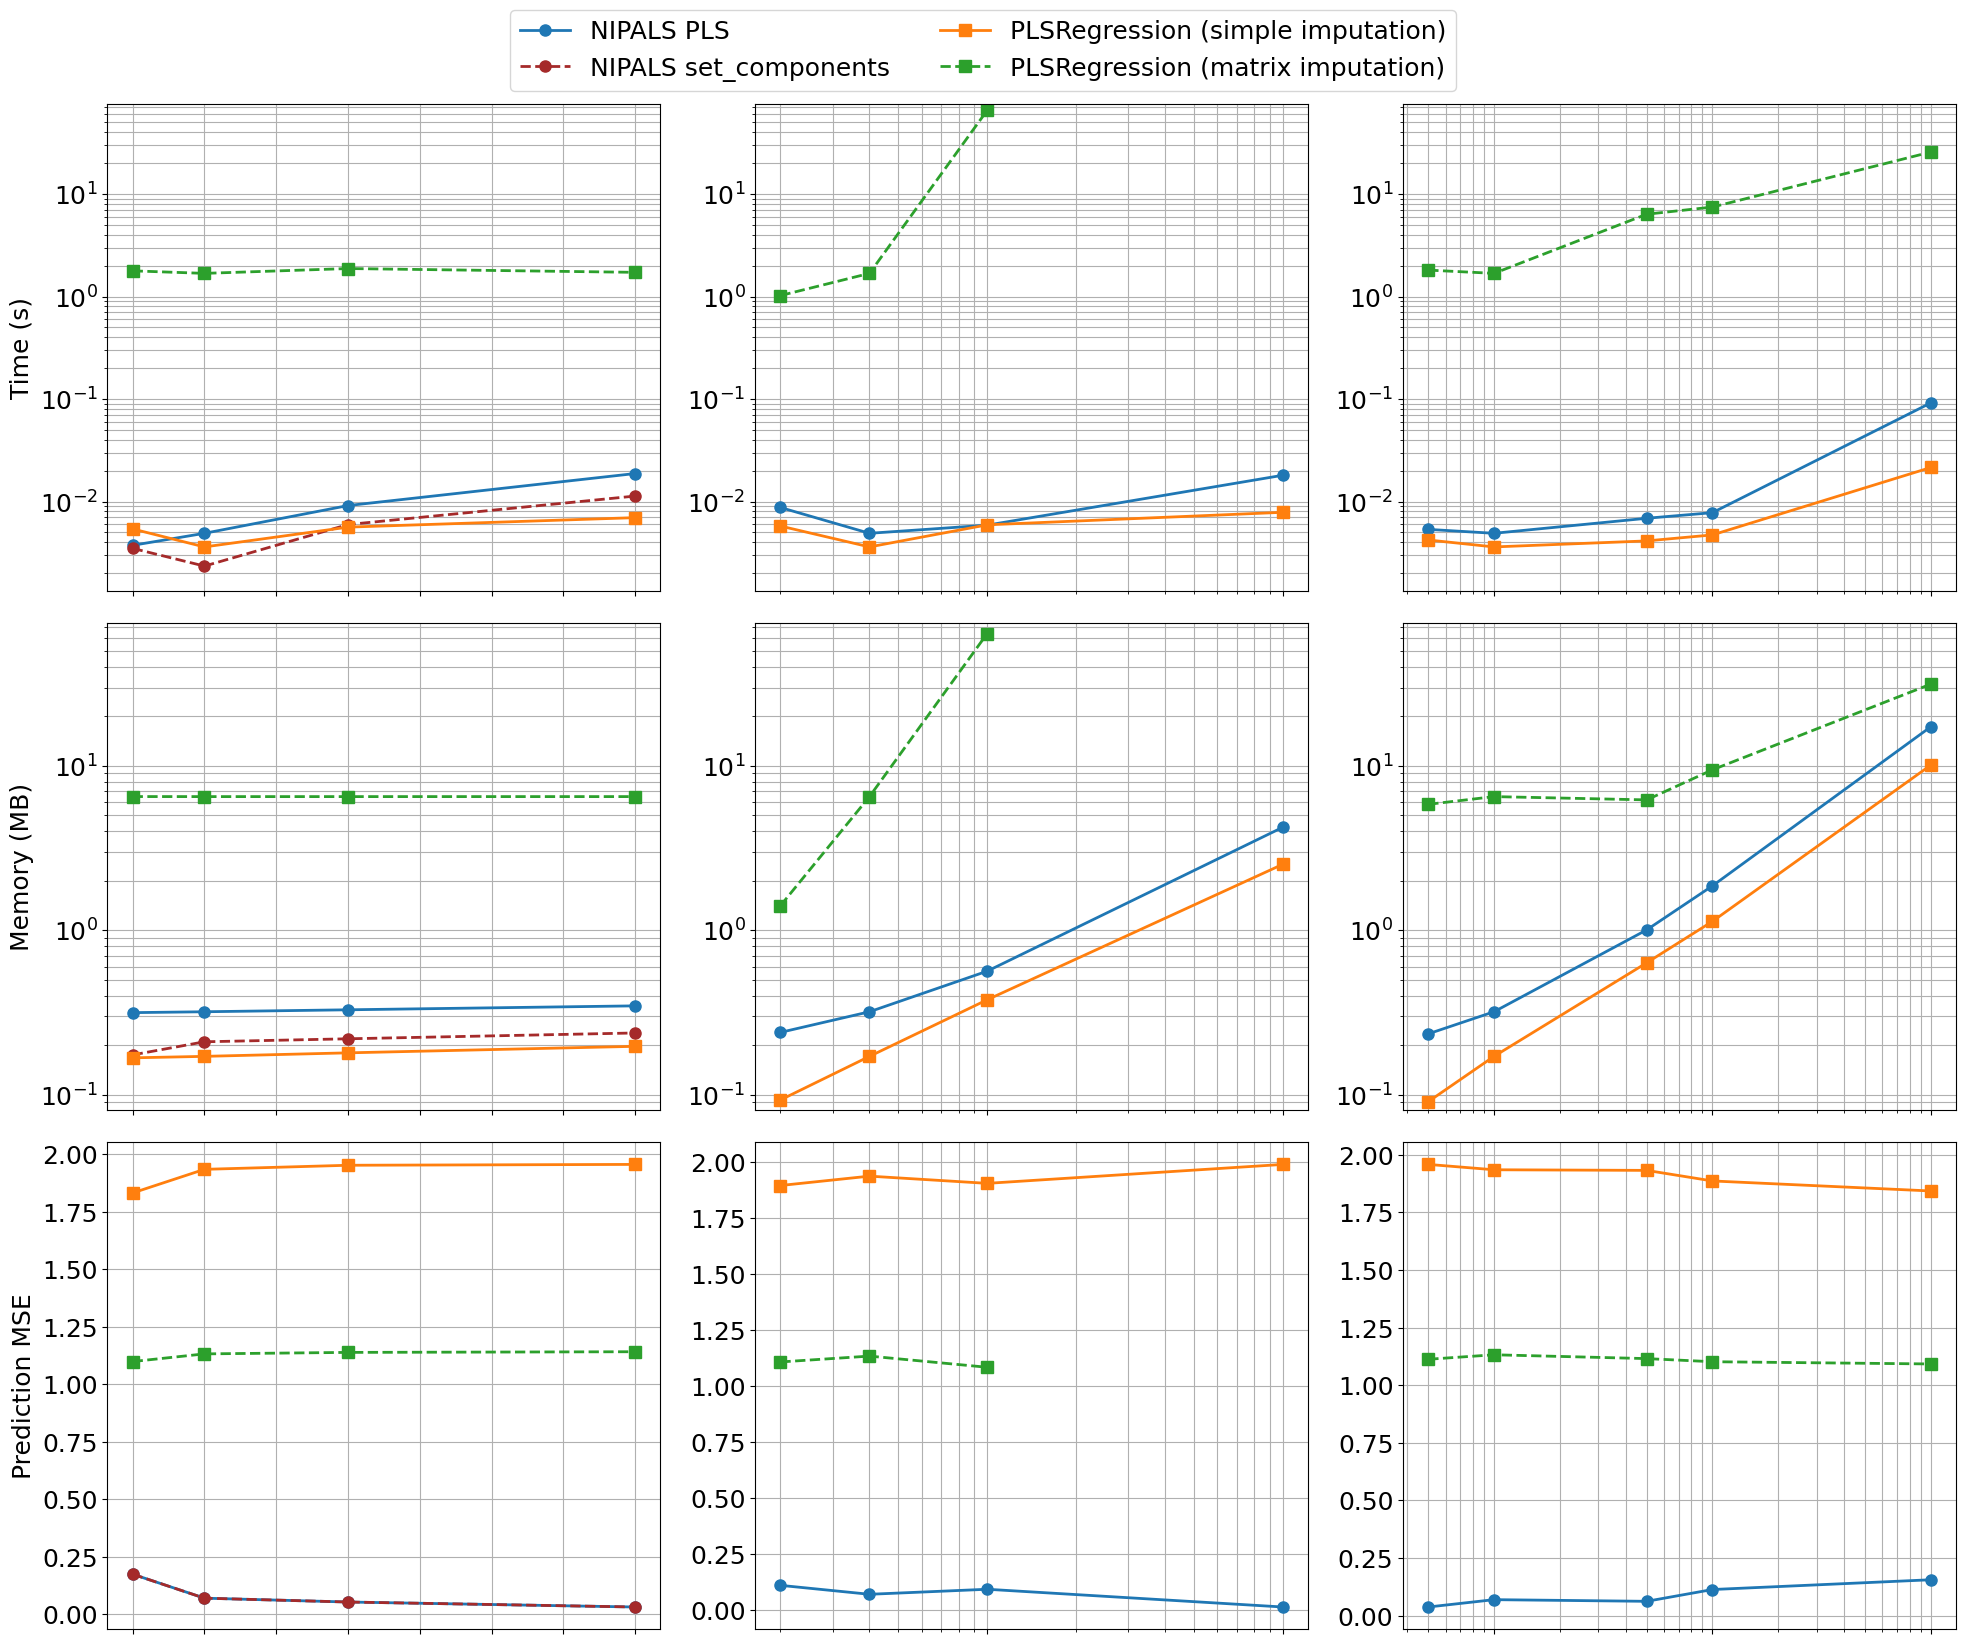

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(20, 16))

# Column 1: Components complexity
# Runtime plot
axes[0, 0].plot(
    loc_df_comp["Components"],
    loc_df_comp["nipals time (s)"],
    "o-",
    linewidth=2,
    markersize=8,
    label="NIPALS PLS",
)
axes[0, 0].plot(
    loc_df_comp["Components"],
    loc_df_comp["set comp nipals time (s)"],
    "o--",
    linewidth=2,
    markersize=8,
    label="NIPALS set_components",
    color="brown",
)
axes[0, 0].plot(
    loc_df_comp["Components"],
    loc_df_comp["PLSRegression simple time (s)"],
    "s-",
    linewidth=2,
    markersize=8,
    label="PLSRegression (simple imputation)",
)
axes[0, 0].plot(
    loc_df_comp["Components"],
    loc_df_comp["PLSRegression matrix time (s)"],
    "s--",
    linewidth=2,
    markersize=8,
    label="PLSRegression (matrix imputation)",
)
axes[0, 0].set_ylabel("Time (s)")
axes[0, 0].set_yscale("log")
axes[0, 0].grid(True, which="both")

# Memory plot
axes[1, 0].plot(
    loc_df_comp["Components"],
    loc_df_comp["nipals memory (MB)"],
    "o-",
    linewidth=2,
    markersize=8,
    label="NIPALS PLS",
)
axes[1, 0].plot(
    loc_df_comp["Components"],
    loc_df_comp["set comp nipals memory (MB)"],
    "o--",
    linewidth=2,
    markersize=8,
    label="NIPALS set_components",
    color="brown",
)
axes[1, 0].plot(
    loc_df_comp["Components"],
    loc_df_comp["PLSRegression simple memory (MB)"],
    "s-",
    linewidth=2,
    markersize=8,
    label="PLSRegression (simple imputation)",
)
axes[1, 0].plot(
    loc_df_comp["Components"],
    loc_df_comp["PLSRegression matrix memory (MB)"],
    "s--",
    linewidth=2,
    markersize=8,
    label="PLSRegression (matrix imputation)",
)
axes[1, 0].set_ylabel("Memory (MB)")
axes[1, 0].set_yscale("log")
axes[1, 0].grid(True, which="both")

# MSE plot
axes[2, 0].plot(
    loc_df_comp["Components"],
    loc_df_comp["nipals MSE"],
    "o-",
    linewidth=2,
    markersize=8,
    label="NIPALS PLS",
)
axes[2, 0].plot(
    loc_df_comp["Components"],
    loc_df_comp["set comp nipals MSE"],
    "o--",
    linewidth=2,
    markersize=8,
    label="NIPALS set_components",
    color="brown",
)
axes[2, 0].plot(
    loc_df_comp["Components"],
    loc_df_comp["PLSRegression simple MSE"],
    "s-",
    linewidth=2,
    markersize=8,
    label="PLSRegression (simple imputation)",
)
axes[2, 0].plot(
    loc_df_comp["Components"],
    loc_df_comp["PLSRegression matrix MSE"],
    "s--",
    linewidth=2,
    markersize=8,
    label="PLSRegression (matrix imputation)",
)
axes[2, 0].set_ylabel("Prediction MSE")
axes[2, 0].grid(True, which="both")


# Column 2: Features complexity
# Runtime plot
axes[0, 1].plot(
    loc_df_feat["Features"],
    loc_df_feat["nipals time (s)"],
    "o-",
    linewidth=2,
    markersize=8,
    label="NIPALS PLS",
)
axes[0, 1].plot(
    loc_df_feat["Features"],
    loc_df_feat["PLSRegression simple time (s)"],
    "s-",
    linewidth=2,
    markersize=8,
    label="PLSRegression (simple imputation)",
)
axes[0, 1].plot(
    loc_df_feat["Features"],
    loc_df_feat["PLSRegression matrix time (s)"],
    "s--",
    linewidth=2,
    markersize=8,
    label="PLSRegression (matrix imputation)",
)
axes[0, 1].set_xscale("log")
axes[0, 1].set_yscale("log")
axes[0, 1].grid(True, which="both")

# Memory plot
axes[1, 1].plot(
    loc_df_feat["Features"],
    loc_df_feat["nipals memory (MB)"],
    "o-",
    linewidth=2,
    markersize=8,
    label="NIPALS PLS",
)
axes[1, 1].plot(
    loc_df_feat["Features"],
    loc_df_feat["PLSRegression simple memory (MB)"],
    "s-",
    linewidth=2,
    markersize=8,
    label="PLSRegression (simple imputation)",
)
axes[1, 1].plot(
    loc_df_feat["Features"],
    loc_df_feat["PLSRegression matrix memory (MB)"],
    "s--",
    linewidth=2,
    markersize=8,
    label="PLSRegression (matrix imputation)",
)
axes[1, 1].set_xscale("log")
axes[1, 1].set_yscale("log")
axes[1, 1].grid(True, which="both")

# MSE plot
axes[2, 1].plot(
    loc_df_feat["Features"],
    loc_df_feat["nipals MSE"],
    "o-",
    linewidth=2,
    markersize=8,
    label="NIPALS PLS",
)
axes[2, 1].plot(
    loc_df_feat["Features"],
    loc_df_feat["PLSRegression simple MSE"],
    "s-",
    linewidth=2,
    markersize=8,
    label="PLSRegression (simple imputation)",
)
axes[2, 1].plot(
    loc_df_feat["Features"],
    loc_df_feat["PLSRegression matrix MSE"],
    "s--",
    linewidth=2,
    markersize=8,
    label="PLSRegression (matrix imputation)",
)
axes[2, 1].set_xscale("log")
axes[2, 1].grid(True, which="both")

# Column 3: Samples complexity
# Runtime plot
axes[0, 2].plot(
    loc_df_samp["Samples"],
    loc_df_samp["nipals time (s)"],
    "o-",
    linewidth=2,
    markersize=8,
    label="NIPALS PLS",
)
axes[0, 2].plot(
    loc_df_samp["Samples"],
    loc_df_samp["PLSRegression simple time (s)"],
    "s-",
    linewidth=2,
    markersize=8,
    label="PLSRegression (simple imputation)",
)
axes[0, 2].plot(
    loc_df_samp["Samples"],
    loc_df_samp["PLSRegression matrix time (s)"],
    "s--",
    linewidth=2,
    markersize=8,
    label="PLSRegression (matrix imputation)",
)
axes[0, 2].set_xscale("log")
axes[0, 2].set_yscale("log")
axes[0, 2].grid(True, which="both")

# Memory plot
axes[1, 2].plot(
    loc_df_samp["Samples"],
    loc_df_samp["nipals memory (MB)"],
    "o-",
    linewidth=2,
    markersize=8,
    label="NIPALS PLS",
)
axes[1, 2].plot(
    loc_df_samp["Samples"],
    loc_df_samp["PLSRegression simple memory (MB)"],
    "s-",
    linewidth=2,
    markersize=8,
    label="PLSRegression (simple imputation)",
)
axes[1, 2].plot(
    loc_df_samp["Samples"],
    loc_df_samp["PLSRegression matrix memory (MB)"],
    "s--",
    linewidth=2,
    markersize=8,
    label="PLSRegression (matrix imputation)",
)
axes[1, 2].set_xscale("log")
axes[1, 2].set_yscale("log")
axes[1, 2].grid(True, which="both")

# MSE plot
axes[2, 2].plot(
    loc_df_samp["Samples"],
    loc_df_samp["nipals MSE"],
    "o-",
    linewidth=2,
    markersize=8,
    label="NIPALS PLS",
)
axes[2, 2].plot(
    loc_df_samp["Samples"],
    loc_df_samp["PLSRegression simple MSE"],
    "s-",
    linewidth=2,
    markersize=8,
    label="PLSRegression (simple imputation)",
)
axes[2, 2].plot(
    loc_df_samp["Samples"],
    loc_df_samp["PLSRegression matrix MSE"],
    "s--",
    linewidth=2,
    markersize=8,
    label="PLSRegression (matrix imputation)",
)
axes[2, 2].set_xscale("log")
axes[2, 2].grid(True, which="both")

# Set y-axes according to global minima and maxima per row
for col in range(3):
    axes[0, col].set_ylim(limits["time"])
    axes[1, col].set_ylim(limits["memory"])

# Remove xticks for top and middle rows
for row in [0, 1, 2]:
    for col in range(3):
        axes[row, col].set_xticklabels([])

# Set integer ticks for components column (column 0)
for row in range(3):
    axes[row, 0].xaxis.set_major_locator(MaxNLocator(integer=True))

# Add a legend to the figure
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=2,
)

plt.tight_layout(rect=[0, 0, 1, 0.99])
if saveflag:
    plt.savefig(
        work_dir.joinpath("..", "plots", "combined_complexity_pls.png"),
        bbox_inches="tight",
        dpi=1200,
    )
plt.show()